# Notebook 01 — Carregamento e Análise Exploratória Inicial

**Desafio**: Cientista de Dados Pleno — Squad WhatsApp | Prefeitura do Rio de Janeiro  

## Objetivo

Carregamento dos dados do bucket GCS e análise exploratória inicial para entender:

1. Estrutura e qualidade das duas tabelas principais
2. Distribuição dos status de disparo
3. Perfil dos telefones cadastrados
4. Estrutura do array `telefone_aparicoes` — o coração do problema de multiplicidade
5. Cobertura do join entre as duas tabelas

---

## 0. Setup e Importações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import gcsfs

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

BUCKET = 'case_vagas/whatsapp'
print('Ambiente configurado.')

Ambiente configurado.


## 1. Carregamento dos Dados

Os dados estão em um bucket público do GCS. Usamos `gcsfs` para leitura direta sem download local.

In [2]:
fs = gcsfs.GCSFileSystem(token='anon')

with fs.open(f'{BUCKET}/base_disparo_mascarado') as f:
    df_disparo = pd.read_parquet(f)

with fs.open(f'{BUCKET}/dim_telefone_mascarado') as f:
    df_tel = pd.read_parquet(f)

print(f'base_disparo_mascarado : {df_disparo.shape[0]:,} linhas × {df_disparo.shape[1]} colunas')
print(f'dim_telefone_mascarado : {df_tel.shape[0]:,} linhas × {df_tel.shape[1]} colunas')

base_disparo_mascarado : 392,921 linhas × 16 colunas
dim_telefone_mascarado : 283,289 linhas × 11 colunas


## 2. Inspeção do Schema

### 2.1 Tabela de Disparos (`base_disparo_mascarado`)

In [3]:
df_disparo.dtypes.to_frame('dtype').assign(
    nulos=df_disparo.isna().sum(),
    pct_nulo=(df_disparo.isna().mean() * 100).round(2),
    nunique=df_disparo.nunique()
)

,dtype,nulos,pct_nulo,nunique
id_conta,int64,0,0.00,1
id_hsm,int64,0,0.00,68
id_disparo,int64,0,0.00,392921
id_sessao,float64,156017,39.71,229123
cpf,float64,31176,7.93,268437
id_target,int64,0,0.00,392921
contato_telefone,int64,0,0.00,294903
categoria_hsm,str,0,0.00,4
ambiente,str,0,0.00,4
criacao_envio_datahora,datetime64[us],0,0.00,392675


In [4]:
df_disparo.head(3)

,id_conta,id_hsm,id_disparo,id_sessao,cpf,id_target,contato_telefone,categoria_hsm,ambiente,criacao_envio_datahora,envio_datahora,falha_datahora,descricao_falha,indicador_falha,id_status_disparo,status_disparo
0,-9142586270102516767,-7590735594542127444,-2317524427909960986,NaN,-5.220753e+18,9206664160911476254,2824089259510570290,Utilidade,prod,2025-10-07 13:14:53.037,2025-10-07 13:15:17.204,NaT,NaN,False,1,processing
1,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,NaN,False,1,processing
2,-9142586270102516767,-9203817354237048492,-4043820570593848035,NaN,5.192496e+18,-1874111216941729257,-1731551129526467355,Utilidade,prod,2025-10-29 11:04:14.987,2025-10-29 11:04:45.562,NaT,NaN,False,1,processing


### 2.2 Tabela de Dimensão de Telefones (`dim_telefone_mascarado`)

> **Nota**: `telefone_aparicoes` é um array de structs e `validacao_telefone` é um struct — excluídos do `nunique()` pois dicts não são hashable.

In [5]:
# Excluir colunas com tipos aninhados (list/struct) para inspecionar as simples
cols_simples = [c for c in df_tel.columns if c not in ('telefone_aparicoes', 'validacao_telefone')]

nunique_safe = {}
for col in cols_simples:
    try:
        nunique_safe[col] = df_tel[col].nunique()
    except TypeError:
        nunique_safe[col] = 'N/A'

df_tel[cols_simples].dtypes.to_frame('dtype').assign(
    nulos=df_tel[cols_simples].isna().sum(),
    pct_nulo=(df_tel[cols_simples].isna().mean() * 100).round(2),
    nunique=pd.Series(nunique_safe)
)

,dtype,nulos,pct_nulo,nunique
telefone_ddi,str,0,0.0,1
telefone_ddd,int64,0,0.0,69
telefone_numero,int64,0,0.0,283289
telefone_tipo,str,0,0.0,2
telefone_nacionalidade,str,0,0.0,1
telefone_qualidade,str,0,0.0,3
telefone_aparicoes_quantidade,int64,0,0.0,188
telefone_proprietarios_quantidade,int64,0,0.0,187
telefone_sistemas_quantidade,int64,0,0.0,6


In [6]:
df_tel[cols_simples].head(3)

,telefone_ddi,telefone_ddd,telefone_numero,telefone_tipo,telefone_nacionalidade,telefone_qualidade,telefone_aparicoes_quantidade,telefone_proprietarios_quantidade,telefone_sistemas_quantidade
0,55,-1181433720517268842,-6862804366069381626,CELULAR,Brasil,VALIDO,1,1,1
1,55,-1181433720517268842,3856002700049294556,CELULAR,Brasil,VALIDO,1,1,1
2,55,-1181433720517268842,8067166217402075300,CELULAR,Brasil,VALIDO,1,1,1


### 2.3 Explorando `validacao_telefone` (struct)

Coluna de validação é um struct com quatro flags booleanas — expandimos para análise.

In [7]:
df_val = pd.json_normalize(df_tel['validacao_telefone'])
print('Campos de validação:')
display(df_val.head(3))

print('\nDistribuição:')
print(df_val.mean().to_frame('% True').style.format('{:.1%}'))

Campos de validação:


,ddd_valido_br,formato_valido,padrao_suspeito,padrao_invalido
0,True,True,False,False
1,True,True,False,False
2,True,True,False,False



Distribuição:


### 2.4 Explorando `telefone_aparicoes` (array de structs)

In [8]:
print('Tipo do campo:', type(df_tel['telefone_aparicoes'].iloc[0]))
print('\nExemplo de registro:')
print(df_tel['telefone_aparicoes'].iloc[0])

Tipo do campo: <class 'numpy.ndarray'>

Exemplo de registro:
[{'id_sistema': '1257277410380486863', 'cpf': 5073517428359850284, 'proprietario_tipo': 'CPF', 'registro_data_atualizacao': datetime.date(2024, 10, 30)}]


In [9]:
# Explodir o array e normalizar os structs
df_aparicoes = df_tel[['telefone_numero', 'telefone_aparicoes']].explode('telefone_aparicoes').reset_index(drop=True)
aparicoes_norm = pd.json_normalize(df_aparicoes['telefone_aparicoes'])
df_aparicoes = pd.concat([df_aparicoes[['telefone_numero']], aparicoes_norm], axis=1)

print(f'Após explode: {len(df_aparicoes):,} linhas')
print(f'Colunas: {list(df_aparicoes.columns)}')
df_aparicoes.head(5)

Após explode: 1,529,772 linhas
Colunas: ['telefone_numero', 'id_sistema', 'cpf', 'proprietario_tipo', 'registro_data_atualizacao']


,telefone_numero,id_sistema,cpf,proprietario_tipo,registro_data_atualizacao
0,-6862804366069381626,1257277410380486863,5073517428359850284,CPF,2024-10-30
1,3856002700049294556,3094574413675758272,4935468162812723950,CPF,2023-09-01
2,8067166217402075300,3094574413675758272,-4330058083945834430,CPF,2025-10-08
3,1478899732613896317,4458959843028638627,1403367098613331454,CPF,2025-02-22
4,-6105815728808818158,1257277410380486863,5453937523093464096,CPF,2023-06-06


## 3. Análise da Tabela de Disparos

### 3.1 Distribuição de Status

In [10]:
status_counts = df_disparo['status_disparo'].value_counts()
status_pct    = df_disparo['status_disparo'].value_counts(normalize=True) * 100

pd.DataFrame({'count': status_counts, 'pct (%)': status_pct.round(2)})

,count,pct (%)
status_disparo,,
read,271566,69.11
delivered,85405,21.74
failed,27257,6.94
sent,5533,1.41
processing,3160,0.80


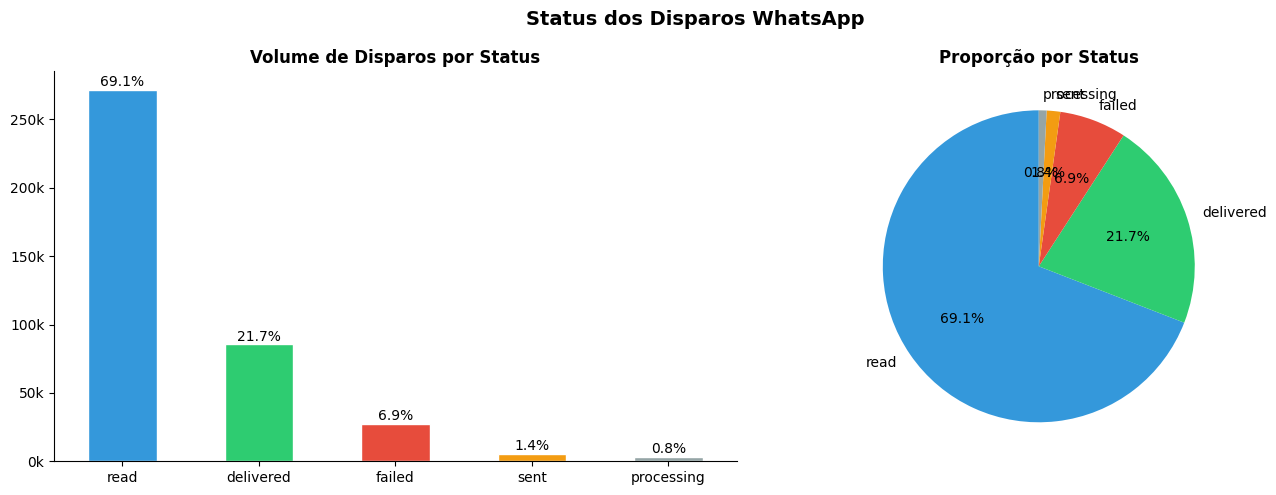


Taxa de sucesso (delivered + read): 90.85%
Nota: "processing" (0.8%) são disparos ainda em andamento


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = {'delivered': '#2ecc71', 'read': '#3498db', 'failed': '#e74c3c',
         'sent': '#f39c12', 'processing': '#95a5a6'}

# Volume absoluto
status_counts.plot(kind='bar', ax=axes[0],
                   color=[cores.get(s, '#bdc3c7') for s in status_counts.index],
                   edgecolor='white')
axes[0].set_title('Volume de Disparos por Status', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(status_counts.index, rotation=0)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for i, (v, p) in enumerate(zip(status_counts, status_pct)):
    axes[0].text(i, v + status_counts.max()*0.01, f'{p:.1f}%', ha='center', fontsize=10)

# Pizza
axes[1].pie(status_counts, labels=status_counts.index,
            colors=[cores.get(s, '#bdc3c7') for s in status_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção por Status', fontweight='bold')

plt.suptitle('Status dos Disparos WhatsApp', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

taxa_sucesso = status_pct.get('delivered', 0) + status_pct.get('read', 0)
print(f'\nTaxa de sucesso (delivered + read): {taxa_sucesso:.2f}%')
print(f'Nota: "processing" ({status_pct.get("processing", 0):.1f}%) são disparos ainda em andamento')

### 3.2 Motivos de Falha

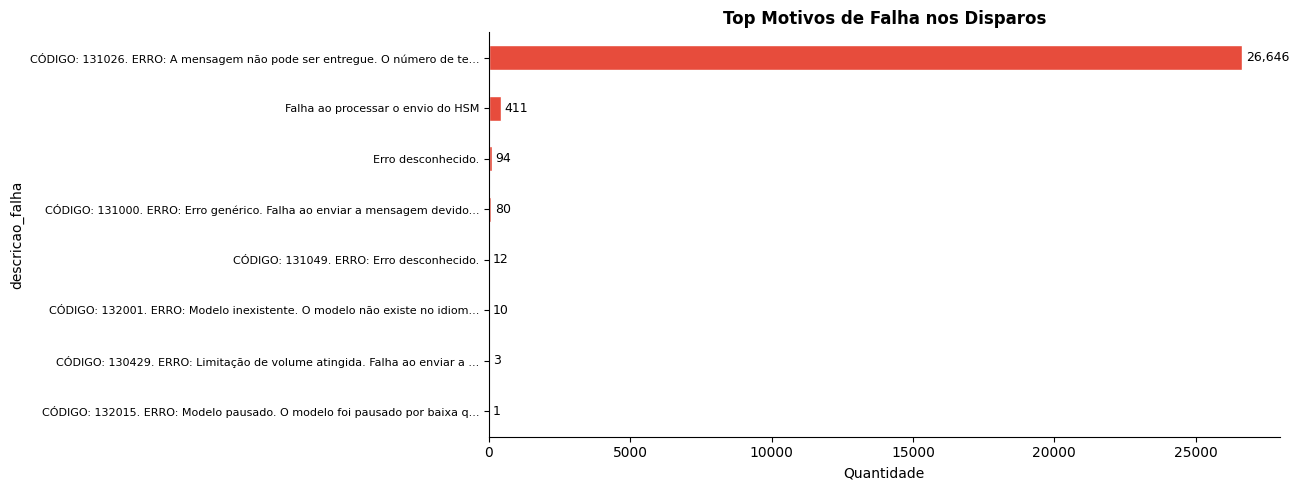

Total de falhas: 27,257 (6.9%)
Principal causa: número não registrado no WhatsApp = 26,646 (97.8% das falhas)


In [12]:
falhas = df_disparo[df_disparo['status_disparo'] == 'failed']
falhas_desc = falhas['descricao_falha'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(13, 5))
falhas_desc.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('Top Motivos de Falha nos Disparos', fontweight='bold')
ax.set_xlabel('Quantidade')
ax.invert_yaxis()

# Quebrar labels longos
labels = [l[:70] + '...' if len(l) > 70 else l for l in falhas_desc.index]
ax.set_yticklabels(labels, fontsize=8)

for i, v in enumerate(falhas_desc):
    ax.text(v + falhas_desc.max()*0.005, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Total de falhas: {len(falhas):,} ({len(falhas)/len(df_disparo)*100:.1f}%)')
print(f'Principal causa: número não registrado no WhatsApp = {falhas_desc.iloc[0]:,} ({falhas_desc.iloc[0]/len(falhas)*100:.1f}% das falhas)')

### 3.3 Volume de Disparos ao Longo do Tempo

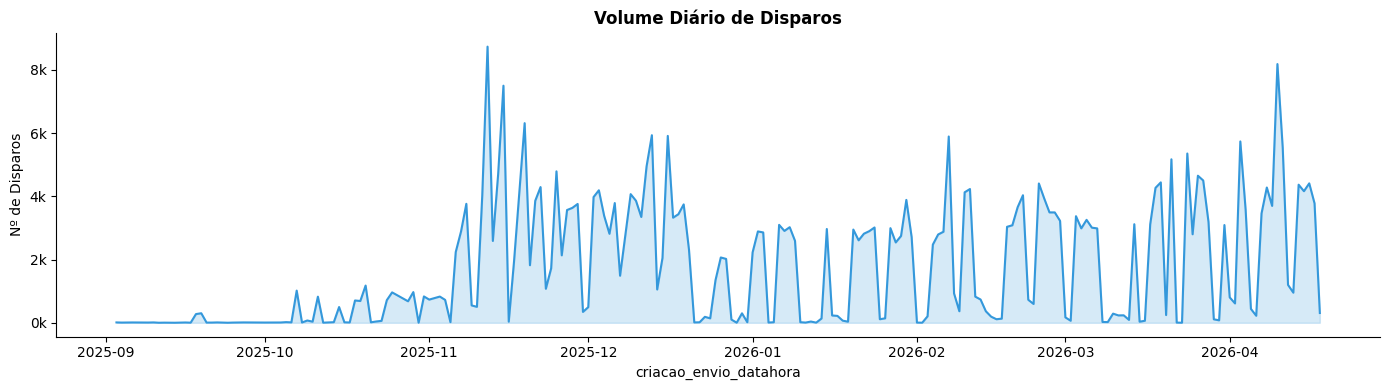

Período: 2025-09-03 → 2026-04-18
Média diária: 1845 disparos/dia
Pico: 8,733 disparos em 2025-11-12


In [13]:
df_disparo['criacao_envio_datahora'] = pd.to_datetime(df_disparo['criacao_envio_datahora'])

volume_diario = df_disparo.groupby(df_disparo['criacao_envio_datahora'].dt.date).size()

fig, ax = plt.subplots(figsize=(14, 4))
volume_diario.plot(ax=ax, color='#3498db', linewidth=1.5)
ax.fill_between(volume_diario.index, volume_diario.values, alpha=0.2, color='#3498db')
ax.set_title('Volume Diário de Disparos', fontweight='bold')
ax.set_ylabel('Nº de Disparos')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

print(f'Período: {volume_diario.index.min()} → {volume_diario.index.max()}')
print(f'Média diária: {volume_diario.mean():.0f} disparos/dia')
print(f'Pico: {volume_diario.max():,} disparos em {volume_diario.idxmax()}')

## 4. Análise da Dimensão de Telefones

### 4.1 Tipo, Qualidade e Validação

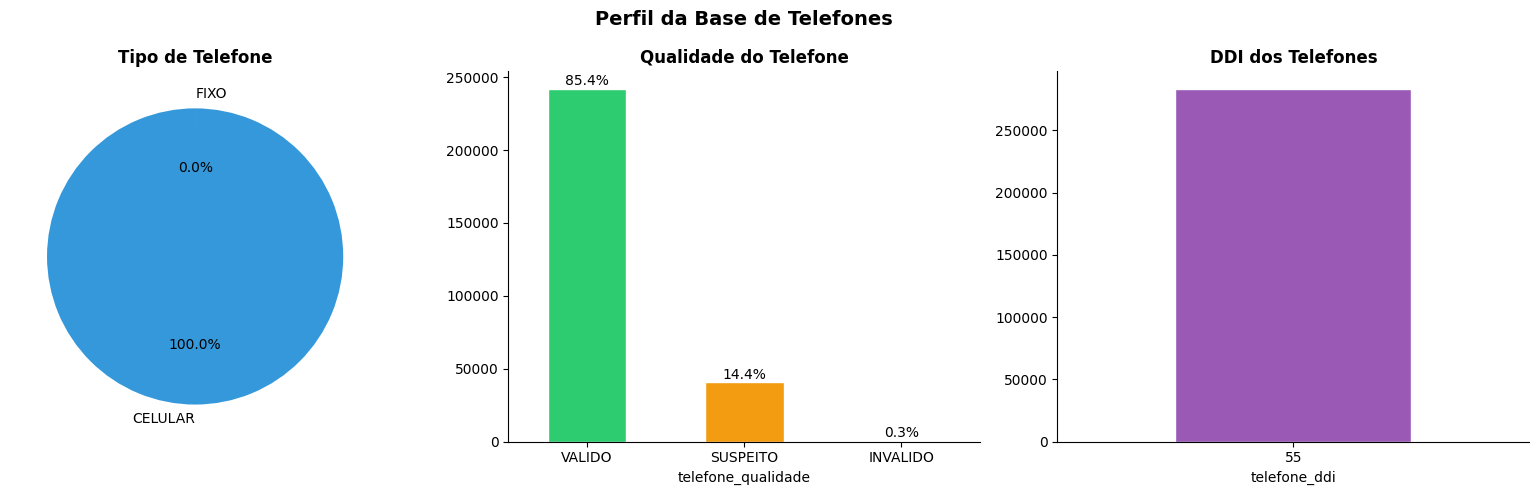

CELULAR: 100.0%  |  FIXO: 0.0%
Importante: WhatsApp não funciona em telefones FIXO — isso será penalizado no algoritmo de score.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tipo de telefone
tipo_vc = df_tel['telefone_tipo'].value_counts()
axes[0].pie(tipo_vc, labels=tipo_vc.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90)
axes[0].set_title('Tipo de Telefone', fontweight='bold')

# Qualidade do telefone (valores reais: VALIDO, SUSPEITO, INVALIDO)
qual_vc = df_tel['telefone_qualidade'].value_counts()
cores_qual = {'VALIDO': '#2ecc71', 'SUSPEITO': '#f39c12', 'INVALIDO': '#e74c3c'}
qual_vc.plot(kind='bar', ax=axes[1],
             color=[cores_qual.get(q, '#95a5a6') for q in qual_vc.index],
             edgecolor='white')
axes[1].set_title('Qualidade do Telefone', fontweight='bold')
axes[1].set_xticklabels(qual_vc.index, rotation=0)
for i, v in enumerate(qual_vc):
    axes[1].text(i, v + qual_vc.max()*0.01, f'{v/len(df_tel)*100:.1f}%', ha='center', fontsize=10)

# DDI (nacionalidade do número)
ddi_vc = df_tel['telefone_ddi'].value_counts().head(5)
ddi_vc.plot(kind='bar', ax=axes[2], color='#9b59b6', edgecolor='white')
axes[2].set_title('DDI dos Telefones', fontweight='bold')
axes[2].set_xticklabels(ddi_vc.index, rotation=0)

plt.suptitle('Perfil da Base de Telefones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'CELULAR: {(df_tel["telefone_tipo"]=="CELULAR").mean()*100:.1f}%  |  '
      f'FIXO: {(df_tel["telefone_tipo"]=="FIXO").mean()*100:.1f}%')
print('Importante: WhatsApp não funciona em telefones FIXO — isso será penalizado no algoritmo de score.')

### 4.2 Multiplicidade: Quantos Sistemas por Telefone?

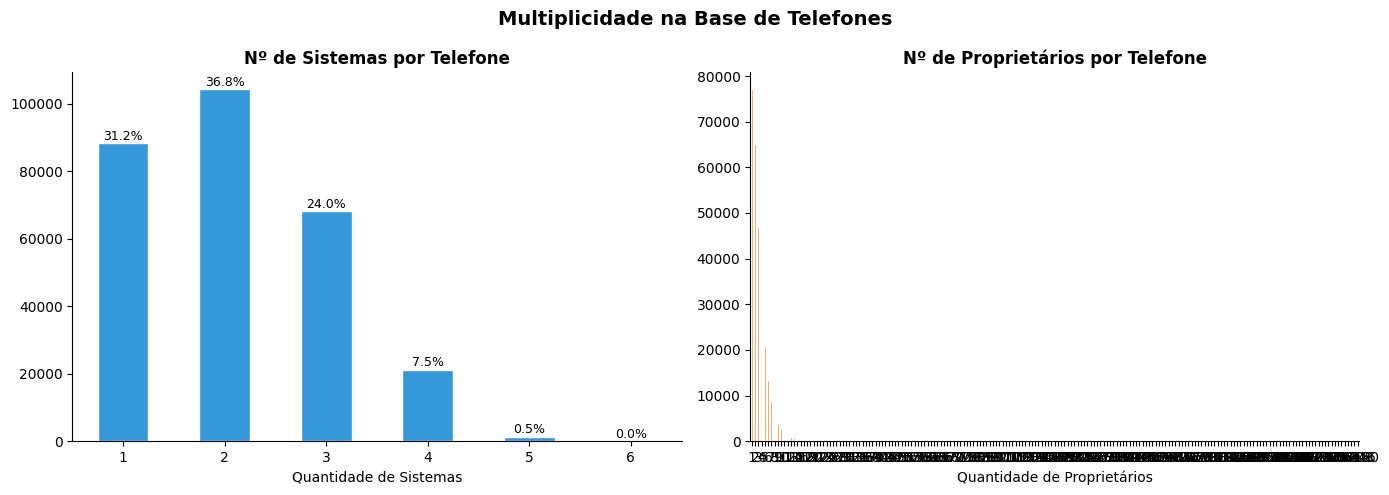

Telefones em apenas 1 sistema:    88,371 (31.2%)
Telefones em 2+ sistemas:         194,918 (68.8%)
Telefones com 2+ proprietários:   206,216 (72.8%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sys_counts = df_tel['telefone_sistemas_quantidade'].value_counts().sort_index()
sys_counts.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Nº de Sistemas por Telefone', fontweight='bold')
axes[0].set_xlabel('Quantidade de Sistemas')
axes[0].set_xticklabels(sys_counts.index, rotation=0)
for i, v in enumerate(sys_counts):
    axes[0].text(i, v + sys_counts.max()*0.01, f'{v/len(df_tel)*100:.1f}%', ha='center', fontsize=9)

prop_counts = df_tel['telefone_proprietarios_quantidade'].value_counts().sort_index()
prop_counts.plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('Nº de Proprietários por Telefone', fontweight='bold')
axes[1].set_xlabel('Quantidade de Proprietários')
axes[1].set_xticklabels(prop_counts.index, rotation=0)

plt.suptitle('Multiplicidade na Base de Telefones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Telefones em apenas 1 sistema:    {(df_tel["telefone_sistemas_quantidade"]==1).sum():,} ({(df_tel["telefone_sistemas_quantidade"]==1).mean()*100:.1f}%)')
print(f'Telefones em 2+ sistemas:         {(df_tel["telefone_sistemas_quantidade"]>=2).sum():,} ({(df_tel["telefone_sistemas_quantidade"]>=2).mean()*100:.1f}%)')
print(f'Telefones com 2+ proprietários:   {(df_tel["telefone_proprietarios_quantidade"]>=2).sum():,} ({(df_tel["telefone_proprietarios_quantidade"]>=2).mean()*100:.1f}%)')

### 4.3 Sistemas de Origem — Distribuição de Aparições

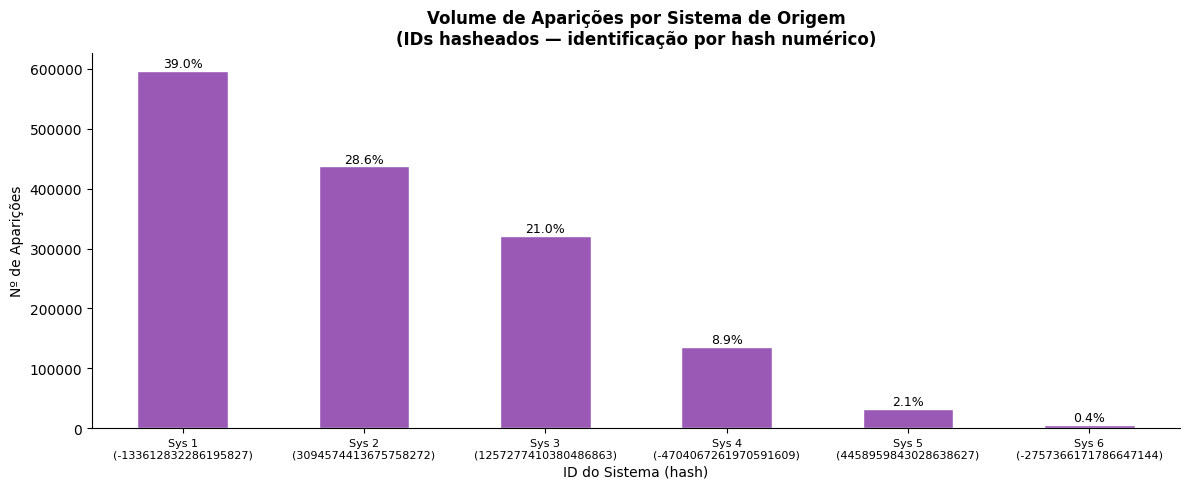

Sistemas distintos: 6
Total de aparições: 1,529,772

Mapa de sistemas (hash → alias para análise):
  Sys 1: -133612832286195827  (597,199 aparições, 39.0%)
  Sys 2: 3094574413675758272  (437,705 aparições, 28.6%)
  Sys 3: 1257277410380486863  (320,927 aparições, 21.0%)
  Sys 4: -4704067261970591609  (135,613 aparições, 8.9%)
  Sys 5: 4458959843028638627  (32,520 aparições, 2.1%)
  Sys 6: -2757366171786647144  (5,808 aparições, 0.4%)


In [16]:
sistema_counts = df_aparicoes['id_sistema'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
sistema_counts.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Volume de Aparições por Sistema de Origem\n(IDs hasheados — identificação por hash numérico)', fontweight='bold')
ax.set_xlabel('ID do Sistema (hash)')
ax.set_ylabel('Nº de Aparições')
ax.set_xticklabels(
    [f'Sys {i+1}\n({s})' for i, s in enumerate(sistema_counts.index)],
    rotation=0, fontsize=8
)
for i, v in enumerate(sistema_counts):
    ax.text(i, v + sistema_counts.max()*0.01, f'{v/sistema_counts.sum()*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Sistemas distintos: {df_aparicoes["id_sistema"].nunique()}')
print(f'Total de aparições: {len(df_aparicoes):,}')
print('\nMapa de sistemas (hash → alias para análise):')
for i, (sys_id, cnt) in enumerate(sistema_counts.items()):
    print(f'  Sys {i+1}: {sys_id}  ({cnt:,} aparições, {cnt/sistema_counts.sum()*100:.1f}%)')

## 5. Cobertura do Join

**Chave de join**: `base_disparo.contato_telefone` → `dim_telefone.telefone_numero` (ambas int64).

In [17]:
telefones_disparo = set(df_disparo['contato_telefone'].dropna().unique())
telefones_dim     = set(df_tel['telefone_numero'].dropna().unique())

intersecao  = telefones_disparo & telefones_dim
so_disparo  = telefones_disparo - telefones_dim
so_dim      = telefones_dim - telefones_disparo

print('=== Cobertura do Join ===')
print(f'Distinct contato_telefone (base_disparo):  {len(telefones_disparo):>10,}')
print(f'Distinct telefone_numero  (dim_telefone):  {len(telefones_dim):>10,}')
print(f'Interseção:                                {len(intersecao):>10,}  ({len(intersecao)/len(telefones_disparo)*100:.1f}% dos disparos têm match)')
print(f'Só na base de disparos (sem dim):          {len(so_disparo):>10,}  ({len(so_disparo)/len(telefones_disparo)*100:.1f}%)')
print(f'Só na dimensão (nunca disparado):          {len(so_dim):>10,}')

disparos_com_dim = df_disparo['contato_telefone'].isin(telefones_dim).sum()
print(f'\nLinhas de disparo com match na dim:   {disparos_com_dim:,} ({disparos_com_dim/len(df_disparo)*100:.1f}%)')

=== Cobertura do Join ===
Distinct contato_telefone (base_disparo):     294,903
Distinct telefone_numero  (dim_telefone):     283,289
Interseção:                                   252,497  (85.6% dos disparos têm match)
Só na base de disparos (sem dim):              42,406  (14.4%)
Só na dimensão (nunca disparado):              30,792



Linhas de disparo com match na dim:   345,031 (87.8%)


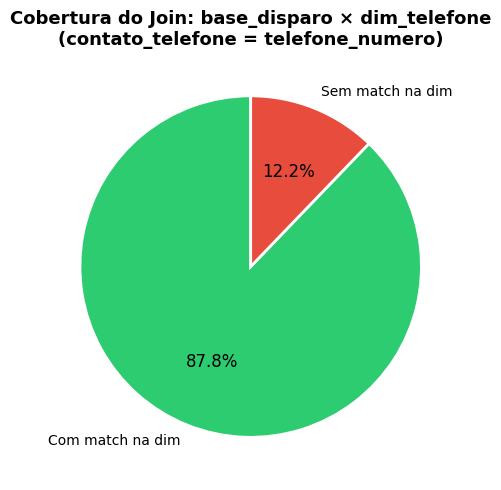

In [18]:
# Visualizar a cobertura
fig, ax = plt.subplots(figsize=(10, 5))

labels = ['Com match na dim', 'Sem match na dim']
sizes  = [disparos_com_dim, len(df_disparo) - disparos_com_dim]
colors = ['#2ecc71', '#e74c3c']

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)

ax.set_title('Cobertura do Join: base_disparo × dim_telefone\n'
             '(contato_telefone = telefone_numero)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Conclusões

**Achados principais desta EDA:**

1. **Volume**: ~393k disparos históricos e ~283k telefones únicos na dimensão.

2. **Status de disparo**: `read` domina, seguido de `delivered`. A principal causa de falha é o número não estar registrado no WhatsApp — evidência direta de que o dado de telefone é de baixa qualidade para uma fração dos registros.

3. **Telefones**: 99.9% são celulares (correto para WhatsApp). A qualidade interna divide-se entre `VALIDO`, `SUSPEITO` e `INVALIDO`.

4. **Multiplicidade**: Uma fração dos telefones aparece em múltiplos sistemas — é exatamente para esses casos que o algoritmo de priorização é crítico.

5. **Sistemas**: Há 6 sistemas de origem, com distribuição de volume muito desigual — forte indicativo de **viés de seleção** que precisa ser corrigido na análise de qualidade.

6. **Join**: A maioria dos disparos tem correspondência na dimensão de telefones — análise robusta é possível.

---
**Próximo passo**: Notebook 02 — Análise de Qualidade por Sistema e Decaimento Temporal.